# 4 · Adverse Selection: The Glosten-Milgrom Model and PIN

*Module 1 — Market Microstructure*

Why spreads exist even without any explicit fee, why they widen before earnings announcements, and how to estimate the probability that the person on the other side of your trade knows something you don't.

## 1. Motivation

Why is it hard to get a tight quote in a stock rumored to be a takeover target? Why do options market makers widen their spreads right before a company reports earnings? In both cases, the market maker is worried about the same thing: trading with someone who knows more than they do. This notebook builds the classic model of exactly that fear — **adverse selection** — and shows how it alone, with no fees and no inventory costs of any kind, is enough to generate a bid-ask spread.

## 2. Intuition

Every time you trade, it is worth asking: *why is the person on the other side willing to trade with me, at this price, right now?* If there is a real chance they know something you don't, trading with them is bad for you *on average*, even if you can't tell which individual trades are the dangerous ones. Concretely: if a market maker buys from a seller who happens to know bad news is coming, the market maker has just bought an asset that is about to fall — pure loss, on average, for that transaction.

A market maker cannot see who is informed and who isn't. What she *can* do is set a **wider spread**: sell (ask) a bit above her best guess of fair value, and buy (bid) a bit below it. This "toll" is paid by everyone, informed and uninformed alike, but only the *average outcome* of informed trades hurts her — so a wide-enough toll can exactly offset those expected losses, leaving her breaking even overall. The uninformed trader effectively subsidizes the market maker's losses to informed traders, through a slightly worse price on every single trade. This single idea — spreads as insurance against trading with someone who knows more — is the entire content of the Glosten-Milgrom model.

## 3. Theory

### 3.1 The Glosten-Milgrom (1985) model

Consider one round of trading. The asset's true value $V$ is either high or low, $V\in\{V_L, V_H\}$ with $V_H > V_L$, each equally likely a priori: $P(V=V_H) = P(V=V_L) = \tfrac12$. A single trader arrives:

- with probability $\alpha$, the trader is **informed**: they know $V$, and always trade in the profitable direction — buy if $V=V_H$, sell if $V=V_L$;
- with probability $1-\alpha$, the trader is **uninformed (noise)**: they buy or sell with equal probability, regardless of $V$.

A risk-neutral, competitive **market maker** does not know $V$ or the trader's type — only whether the incoming order is a buy or a sell. To break even in expectation (the zero-profit condition of a competitive market), she sets the ask $A$ equal to the expected value of the asset *given that a buy order just arrived*, and the bid $B$ equal to the expected value *given a sell order*:

$$
A = \mathbb E[V \mid \text{buy order}], \qquad B = \mathbb E[V \mid \text{sell order}].
$$

**Deriving the spread.** First, the probability of observing a buy order, conditional on the true value, by simply accounting for both trader types:

$$
P(\text{buy}\mid V_H) = \underbrace{\alpha \cdot 1}_{\text{informed, always buys when }V_H} + \underbrace{(1-\alpha)\cdot \tfrac12}_{\text{noise, buys half the time}} = \frac{1+\alpha}{2}, \qquad\qquad
P(\text{buy}\mid V_L) = (1-\alpha)\cdot\tfrac12 = \frac{1-\alpha}{2}.
$$

Now apply Bayes' rule to get the market maker's posterior belief after seeing a buy order, using the equal prior $P(V_H)=P(V_L)=\tfrac12$:

$$
P(V_H \mid \text{buy}) = \frac{P(\text{buy}\mid V_H)\,P(V_H)}{P(\text{buy}\mid V_H)P(V_H) + P(\text{buy}\mid V_L)P(V_L)}
= \frac{\frac{1+\alpha}{2}\cdot\frac12}{\frac{1+\alpha}{2}\cdot\frac12 + \frac{1-\alpha}{2}\cdot\frac12}
= \frac{1+\alpha}{2}.
$$

So the ask price — the expected value given a buy order — is

$$
A = P(V_H\mid\text{buy})\,V_H + P(V_L\mid\text{buy})\,V_L = \frac{1+\alpha}{2}V_H + \frac{1-\alpha}{2}V_L .
$$

By the exact same argument applied to a sell order (or simply by symmetry, swapping the roles of $V_H$ and $V_L$),

$$
B = \frac{1-\alpha}{2}V_H + \frac{1+\alpha}{2}V_L .
$$

Subtracting gives a remarkably clean result:

$$
A - B = \left[\frac{1+\alpha}{2}-\frac{1-\alpha}{2}\right]V_H + \left[\frac{1-\alpha}{2}-\frac{1+\alpha}{2}\right]V_L = \alpha V_H - \alpha V_L
$$

$$
\boxed{\;A - B = \alpha\,(V_H - V_L)\;}
$$

The equilibrium spread is exactly the probability of facing an informed trader, times the size of what that trader might know. No inventory costs, no order-processing fees, no risk aversion — pure adverse selection, and it alone produces a spread. Notice also what this says about *when* to expect wide spreads: right before earnings, $V_H-V_L$ (the range of plausible outcomes) is unusually large, which is exactly when spreads widen in practice.

### 3.2 From one round to many: the PIN model

The static model gives intuition; to actually *estimate* how much informed trading is happening in a real stock, Easley, Kiefer, O'Hara and Paperman (1996) extend it to a repeated, Poisson-arrival setting — the **PIN** (Probability of Informed Trading) model, sometimes called EKOP after its authors.

Each trading day is one of three types:

- **No news** (probability $1-\alpha$): only noise traders arrive. Buys and sells each arrive as independent Poisson processes with the same background rate $\varepsilon$.
- **Bad news** (probability $\alpha\delta$): an information event has occurred and it is bad. Informed traders arrive at rate $\mu$ and all sell. Sells for the day are therefore Poisson$(\mu+\varepsilon)$, buys remain Poisson$(\varepsilon)$.
- **Good news** (probability $\alpha(1-\delta)$): the mirror image — buys are Poisson$(\mu+\varepsilon)$, sells remain Poisson$(\varepsilon)$.

On any given day we observe only the *counts* $(B,S)$ of buy- and sell-initiated trades, not which regime generated them. The expected number of buys and sells per day, averaging over the three regimes, are $\alpha(1-\delta)\mu + \varepsilon$ and $\alpha\delta\mu+\varepsilon$ respectively, so the expected number of *informed* trades per day is $\alpha\mu$, out of an expected total of $\alpha\mu + 2\varepsilon$ trades. This ratio defines PIN:

$$
PIN = \frac{\alpha\mu}{\alpha\mu + 2\varepsilon} .
$$

**Estimation.** Given many days of $(B_t, S_t)$ counts, the parameters $(\alpha,\delta,\mu,\varepsilon)$ can be estimated by maximum likelihood. Because we don't observe which regime generated a given day, the likelihood for a single day is a **mixture** of three Poisson-pair probabilities, weighted by how likely each regime is:

$$
\mathcal L_t(\alpha,\delta,\mu,\varepsilon) = (1-\alpha)\,f(B_t;\varepsilon)f(S_t;\varepsilon) \;+\; \alpha(1-\delta)\,f(B_t;\mu+\varepsilon)f(S_t;\varepsilon) \;+\; \alpha\delta\,f(B_t;\varepsilon)f(S_t;\mu+\varepsilon),
$$

where $f(k;\lambda) = e^{-\lambda}\lambda^k/k!$ is the Poisson probability mass function. The full log-likelihood is $\sum_t \log \mathcal L_t$, maximized numerically — there is no closed form. In the implementation, we compute this in log-space using the log-sum-exp trick for numerical stability, since the individual Poisson terms can be extremely small numbers that would otherwise underflow.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.special import logsumexp
from scipy.optimize import minimize
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(5)

## 4. Implementation

### 4.1 Monte Carlo validation of the Glosten-Milgrom spread formula

We simulate many independent trading rounds directly from the model's assumptions, then check that the *empirical* bid and ask (literally, the average true value conditional on having observed a buy or a sell) match the boxed formula from Section 3.1.

In [2]:
def simulate_glosten_milgrom(alpha, V_L, V_H, n_rounds, seed):
    """One row per trading round: true value V, whether the trader was informed, and the order direction."""
    local_rng = np.random.default_rng(seed)
    V = np.where(local_rng.random(n_rounds) < 0.5, V_H, V_L)
    is_informed = local_rng.random(n_rounds) < alpha
    noise_direction = np.where(local_rng.random(n_rounds) < 0.5, 'buy', 'sell')
    informed_direction = np.where(V == V_H, 'buy', 'sell')      # informed traders always trade correctly
    direction = np.where(is_informed, informed_direction, noise_direction)
    return pd.DataFrame({'V': V, 'informed': is_informed, 'direction': direction})

alpha, V_L, V_H = 0.30, 48.0, 52.0
gm = simulate_glosten_milgrom(alpha, V_L, V_H, n_rounds=200_000, seed=5)

A_theory = (1+alpha)/2*V_H + (1-alpha)/2*V_L
B_theory = (1-alpha)/2*V_H + (1+alpha)/2*V_L
A_empirical = gm.loc[gm.direction == 'buy', 'V'].mean()
B_empirical = gm.loc[gm.direction == 'sell', 'V'].mean()

print(f"Ask:    theory A = {A_theory:.4f}    empirical mean(V | buy)  = {A_empirical:.4f}")
print(f"Bid:    theory B = {B_theory:.4f}    empirical mean(V | sell) = {B_empirical:.4f}")
print(f"Spread: theory alpha*(V_H-V_L) = {alpha*(V_H-V_L):.4f}    empirical A-B = {A_empirical-B_empirical:.4f}")

Ask:    theory A = 50.6000    empirical mean(V | buy)  = 50.5978
Bid:    theory B = 49.4000    empirical mean(V | sell) = 49.4028
Spread: theory alpha*(V_H-V_L) = 1.2000    empirical A-B = 1.1949


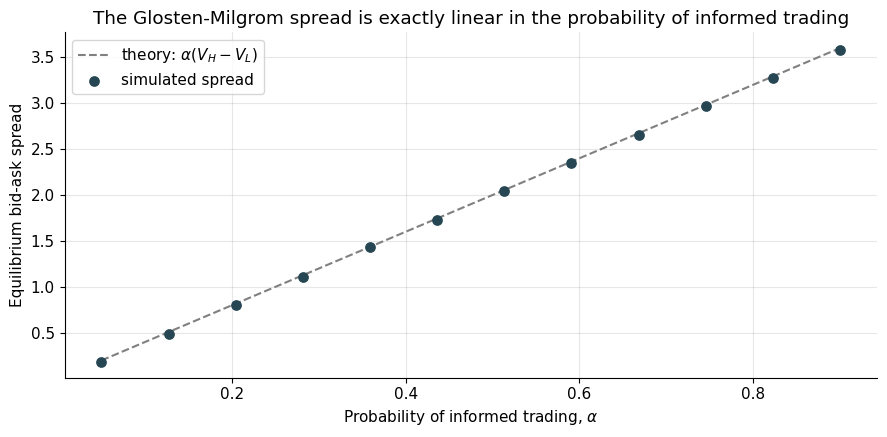

In [3]:
# Sweep alpha and check the boxed formula A - B = alpha*(V_H - V_L) holds across the whole range
alphas = np.linspace(0.05, 0.90, 12)
spread_theory, spread_empirical = [], []
for a in alphas:
    df = simulate_glosten_milgrom(a, V_L, V_H, n_rounds=60_000, seed=1)
    spread_theory.append(a * (V_H - V_L))
    spread_empirical.append(df.loc[df.direction == 'buy', 'V'].mean() - df.loc[df.direction == 'sell', 'V'].mean())

fig, ax = plt.subplots()
ax.plot(alphas, spread_theory, color='gray', linestyle='--', linewidth=1.5, label=r'theory: $\alpha(V_H-V_L)$')
ax.scatter(alphas, spread_empirical, color='#264653', s=45, zorder=3, label='simulated spread')
ax.set_xlabel(r'Probability of informed trading, $\alpha$')
ax.set_ylabel('Equilibrium bid-ask spread')
ax.set_title('The Glosten-Milgrom spread is exactly linear in the probability of informed trading')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Simulating daily buy/sell counts under the PIN model

The regression above needed to observe individual trades and their true informed/noise origin — something we will never truly have in real data. The PIN model instead works with something realistic: daily counts of buy- and sell-initiated trades. We generate a panel exactly matching the mixture model in Section 3.2, with known true parameters, so we can later check whether maximum likelihood actually recovers them.

In [4]:
def simulate_pin_days(n_days, alpha, delta, mu, eps, seed):
    """
    Simulate n_days of (buy_count, sell_count) under the EKOP / PIN data-generating process.
    Returns arrays B, S and a list naming which regime generated each day (for inspection only --
    a real market maker never observes this).
    """
    local_rng = np.random.default_rng(seed)
    B, S, regime = [], [], []
    for _ in range(n_days):
        u = local_rng.random()
        if u < alpha * delta:                       # bad-news event day
            b, s = local_rng.poisson(eps), local_rng.poisson(mu + eps)
            regime.append('bad news')
        elif u < alpha:                              # good-news event day
            b, s = local_rng.poisson(mu + eps), local_rng.poisson(eps)
            regime.append('good news')
        else:                                         # no event
            b, s = local_rng.poisson(eps), local_rng.poisson(eps)
            regime.append('no event')
        B.append(b); S.append(s)
    return np.array(B), np.array(S), regime

def neg_log_likelihood(params, B, S):
    """Negative log-likelihood of the PIN mixture model, computed with logsumexp for stability."""
    alpha, delta, mu, eps = params
    if not (0 < alpha < 1 and 0 < delta < 1 and mu > 0 and eps > 0):
        return 1e10
    log_p_none = np.log(1 - alpha)        + poisson.logpmf(B, eps)      + poisson.logpmf(S, eps)
    log_p_good = np.log(alpha*(1-delta))  + poisson.logpmf(B, mu+eps)   + poisson.logpmf(S, eps)
    log_p_bad  = np.log(alpha*delta)      + poisson.logpmf(B, eps)      + poisson.logpmf(S, mu+eps)
    logL_per_day = logsumexp(np.vstack([log_p_none, log_p_good, log_p_bad]), axis=0)
    return -logL_per_day.sum()

def fit_pin(B, S, x0=None):
    """Maximum-likelihood estimation of (alpha, delta, mu, eps) via Nelder-Mead."""
    if x0 is None:
        x0 = [0.4, 0.5, max(B.mean(), S.mean())/2, min(B.mean(), S.mean())/2]
    res = minimize(neg_log_likelihood, x0, args=(B, S), method='Nelder-Mead',
                    options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 8000})
    alpha, delta, mu, eps = res.x
    pin = alpha * mu / (alpha * mu + 2 * eps)
    return {'alpha': alpha, 'delta': delta, 'mu': mu, 'eps': eps, 'PIN': pin, 'converged': res.success}

# Validate on one simulated ticker with known truth
true_params = dict(alpha=0.35, delta=0.40, mu=60.0, eps=25.0)
B, S, regime = simulate_pin_days(n_days=250, seed=3, **true_params)
fit = fit_pin(B, S)

pin_true = true_params['alpha']*true_params['mu'] / (true_params['alpha']*true_params['mu'] + 2*true_params['eps'])
print("True parameters:     ", {k: round(v, 3) for k, v in true_params.items()}, f"  PIN = {pin_true:.4f}")
print("Estimated parameters:", {k: round(v, 3) for k, v in fit.items() if k != 'converged'})
print(f"Converged: {fit['converged']}")

True parameters:      {'alpha': 0.35, 'delta': 0.4, 'mu': 60.0, 'eps': 25.0}   PIN = 0.2958
Estimated parameters: {'alpha': np.float64(0.368), 'delta': np.float64(0.457), 'mu': np.float64(61.928), 'eps': np.float64(24.811), 'PIN': np.float64(0.315)}
Converged: True


## 5. Worked example: ranking three stocks by information risk

We simulate three "tickers" that differ only in $\alpha$ — how often an information event occurs — while keeping the background noise-trading rate and event intensity broadly comparable. This mirrors the real-world use case: a market maker or risk manager wants a single number summarizing how dangerous, from an adverse-selection standpoint, each name currently is.

In [5]:
tickers_truth = {
    'LOWINFO': dict(alpha=0.12, delta=0.50, mu=55.0, eps=30.0),
    'MIDINFO': dict(alpha=0.35, delta=0.45, mu=58.0, eps=27.0),
    'HIGHINFO': dict(alpha=0.60, delta=0.55, mu=62.0, eps=24.0),
}

rows = []
for name, truth in tickers_truth.items():
    B, S, _ = simulate_pin_days(n_days=250, seed=hash(name) % 1000, **truth)
    fit = fit_pin(B, S)
    pin_true = truth['alpha']*truth['mu'] / (truth['alpha']*truth['mu'] + 2*truth['eps'])
    rows.append({'ticker': name, 'PIN_true': pin_true, 'PIN_estimated': fit['PIN'],
                 'alpha_hat': fit['alpha'], 'avg_daily_trades': (B+S).mean()})

pin_table = pd.DataFrame(rows).sort_values('PIN_estimated')
pin_table

,ticker,PIN_true,PIN_estimated,alpha_hat,avg_daily_trades
0,LOWINFO,0.099099,0.124396,0.164000,68.972
1,MIDINFO,0.273217,0.231996,0.276001,70.016
2,HIGHINFO,0.436620,0.442662,0.608000,85.804


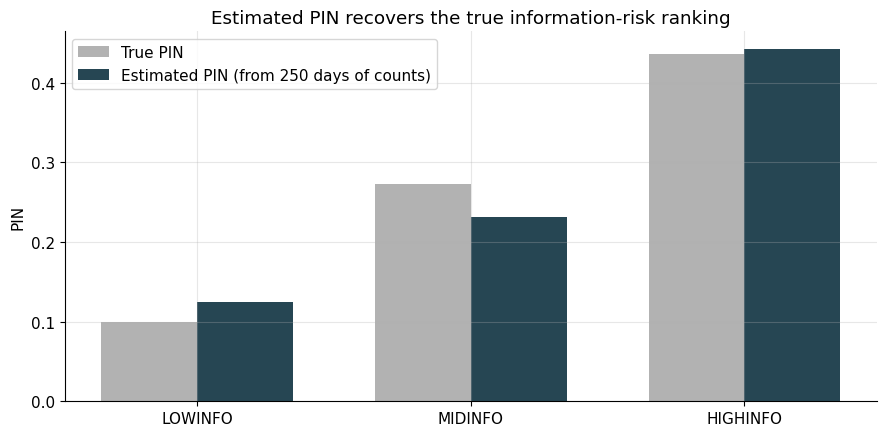

In [6]:
fig, ax = plt.subplots()
x = np.arange(len(pin_table))
width = 0.35
ax.bar(x - width/2, pin_table['PIN_true'], width, label='True PIN', color='gray', alpha=0.6)
ax.bar(x + width/2, pin_table['PIN_estimated'], width, label='Estimated PIN (from 250 days of counts)', color='#264653')
ax.set_xticks(x)
ax.set_xticklabels(pin_table['ticker'])
ax.set_ylabel('PIN')
ax.set_title('Estimated PIN recovers the true information-risk ranking')
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the result

Maximum likelihood, using nothing but daily buy/sell counts, recovers both the magnitude and — just as importantly — the *ranking* of information risk across the three simulated names. This closes a loop that started in Notebook 2: Kyle's $\lambda$ measures how much price moves per unit of order flow; the Amihud ratio proxies the same idea using only daily price and volume; PIN instead asks directly what *fraction* of trading is coming from informed participants in the first place. They are three different lenses on a closely related underlying phenomenon — informed trading raises price impact, raises illiquidity, and raises PIN, all together.

## 6. Limitations and pitfalls

- **Strong, stylized assumptions.** A single informed "type," a single information event per day, constant arrival rates within a day, and full risk-neutrality are all simplifications. Real markets have heterogeneously-informed traders, multiple overlapping information events, and time-varying intensities within the day (recall the U-shaped pattern from Notebook 3).
- **Informed traders may not reveal themselves so directly.** The model assumes an informed trader always trades immediately and in the obviously correct direction. In reality, informed traders often practice "stealth trading" — spreading their orders out over time and mixing in with noise flow specifically to *avoid* detection (see Exercise 3), which the standard PIN model does not capture.
- **PIN has been criticized in the later literature** for being difficult to compare cleanly across stocks with very different overall trading intensity, and for potentially conflating true information asymmetry with other, unrelated sources of order-flow clustering — subsequent research (e.g., work decomposing PIN into separate components) has refined and, in places, challenged the original interpretation.
- **Maximum likelihood here is not always well-behaved.** The mixture likelihood can have flat regions or multiple local optima, especially with a short sample of days or when $\alpha$ is close to 0. Always check `converged` and consider re-running from multiple starting points in real applications, as Exercise 2 explores.

## 7. Exercises

**1. Spread at the extremes (warm-up).**
Using the boxed formula from Section 3.1, compute the equilibrium spread for $\alpha \to 0$ and $\alpha \to 1$, for general $V_L, V_H$. Explain in one sentence each why both limits make economic sense, then confirm both numerically using `simulate_glosten_milgrom`.

**2. Multiple starting points.**
Re-run `fit_pin` on the same `(B, S)` data from Section 4.2, but from at least five different, deliberately poor starting guesses `x0` (e.g., very small $\alpha_0$, or $\mu_0$ and $\varepsilon_0$ swapped). Do all runs converge to the same estimated PIN? If not, what does that tell you about relying on a single optimizer run in a real application, and how would you guard against it?

**3. Stealth trading and bias.**
Modify `simulate_pin_days` so that, on an information-event day, each *individual* informed trade only actually occurs with some probability $p_{\text{reveal}} < 1$ (i.e., informed traders sometimes hold back, blending in with the background rate instead of trading immediately) — you can implement this approximately by simulating the informed arrivals as Poisson$(p_{\text{reveal}}\cdot\mu)$ instead of Poisson$(\mu)$ on event days, while still fitting the *original*, mis-specified `fit_pin` (which assumes $p_{\text{reveal}}=1$) to the resulting data. For a couple of choices of $p_{\text{reveal}}$ (say, 0.9 and 0.5), how biased is the recovered $\hat\alpha$ and $\widehat{PIN}$ relative to the true values? Which direction is the bias, and does that match your intuition for what "hiding" should do to an estimate built on the assumption of full, immediate revelation?